# Validate Saved Checkpoint

This notebook loads the best saved model checkpoint and evaluates it on the validation split.
It prints IoU, precision, recall, F1, and saves a JSON metrics file.


In [1]:
import sys
from pathlib import Path

print('Python executable:', sys.executable)
print('Working directory:', Path.cwd())


Python executable: C:\Users\Rayhan Akhtar\OneDrive\Desktop\project\.venv\Scripts\python.exe
Working directory: C:\Users\Rayhan Akhtar\OneDrive\Desktop\project\notebooks


In [2]:
import sys
from pathlib import Path
from pprint import pprint

import yaml

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.eval import evaluate

config_path = project_root / 'config.yaml'
checkpoint_path = project_root / 'checkpoints' / 'best.pth'
data_path = project_root / 'dataset' / 'val'
output_dir = project_root / 'results_val_notebook'

with config_path.open('r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

config['device'] = 'cpu'

if not checkpoint_path.exists():
    raise FileNotFoundError(f'Missing checkpoint: {checkpoint_path}')

metrics = evaluate(
    config=config,
    data_path=str(data_path),
    weights_path=str(checkpoint_path),
    output_dir=str(output_dir),
)

print()
print('Validation metrics:')
pprint(metrics)
print()
print(f'Saved metrics JSON to: {output_dir / "evaluation_metrics.json"}')


Using device: cpu



Evaluating:   0%|          | 0/21 [00:00<?, ?it/s]


Evaluating:   5%|▍         | 1/21 [00:02<00:53,  2.66s/it]


Evaluating:  10%|▉         | 2/21 [00:05<00:48,  2.53s/it]


Evaluating:  14%|█▍        | 3/21 [00:07<00:48,  2.69s/it]

...


Evaluating:  90%|█████████ | 19/21 [00:49<00:05,  2.57s/it]


Evaluating:  95%|█████████▌| 20/21 [00:52<00:02,  2.59s/it]


Evaluating: 100%|██████████| 21/21 [00:54<00:00,  2.47s/it]


Evaluating: 100%|██████████| 21/21 [00:54<00:00,  2.60s/it]


Evaluation Results:
  IoU:       0.5284
  Precision: 0.7486
  Recall:    0.6425
  F1 Score:  0.6915
  Saved:     C:\Users\Rayhan Akhtar\OneDrive\Desktop\project\results_val_notebook\evaluation_metrics.json

Validation metrics:
{'confusion_matrix': [[21303503, 103929], [172186, 309406]],
 'f1': 0.6914664498348819,
 'iou': 0.5284285277556138,
 'precision': 0.7485598848391559,
 'recall': 0.6424649911127959}

Saved metrics JSON to: C:\Users\Rayhan Akhtar\OneDrive\Desktop\project\results_val_notebook\evaluation_metrics.json


Sample 1: scene_06_000060_building_damage.tif
  Status: False prediction | Accuracy: 0.9187 | Precision: 0.8500 | Recall: 0.8996 | F1: 0.8741 | IoU: 0.7764 | Change presence match: True | Correct prediction: False
Sample 2: scene_06_000078_building_damage.tif
  Status: False prediction | Accuracy: 0.9997 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | IoU: 0.0000 | Change presence match: False | Correct prediction: False
Sample 3: scene_06_000047_building_damage.tif
  Status: Correct prediction | Accuracy: 1.0000 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | IoU: 0.0000 | Change presence match: True | Correct prediction: True
Sample 4: scene_08_000035_building_damage.tif
  Status: Correct prediction | Accuracy: 1.0000 | Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000 | IoU: 0.0000 | Change presence match: True | Correct prediction: True


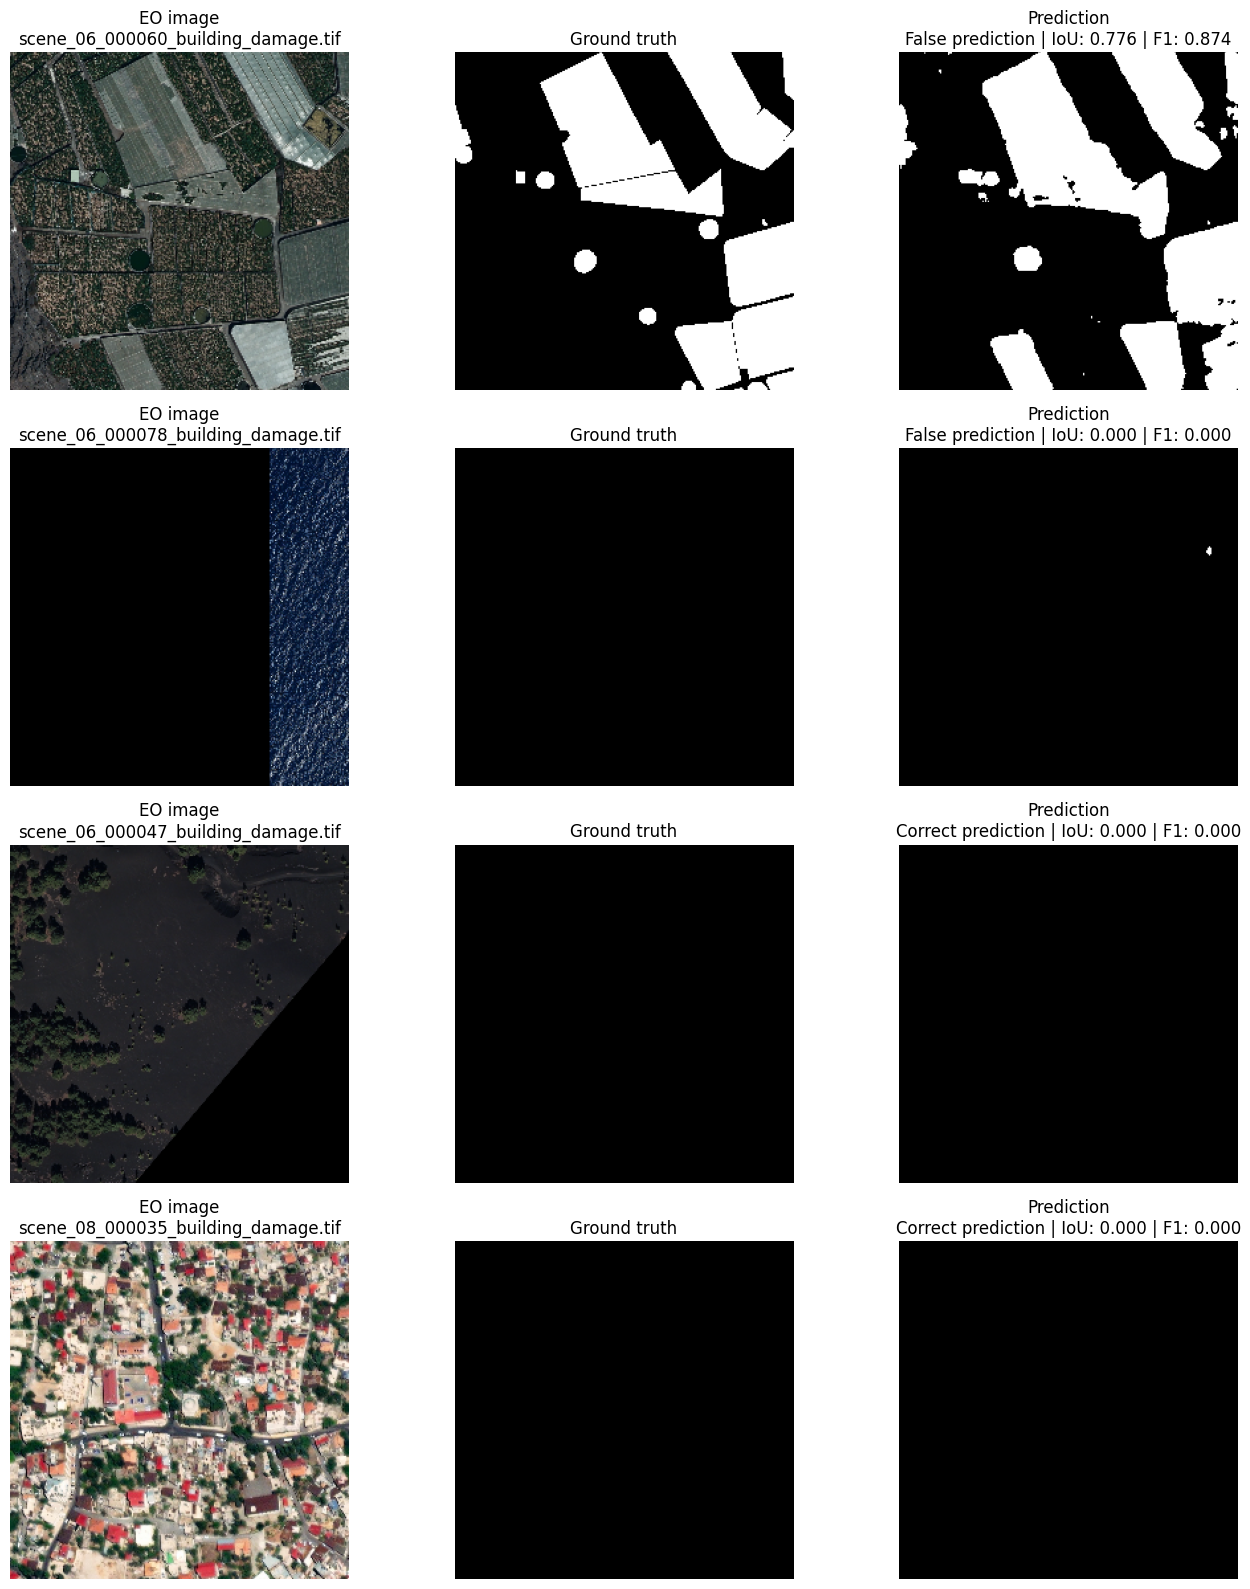

In [8]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data.dataset import ChangeDetectionDataset
from src.models.siamese_unet import build_model
from src.utils.metrics import logits_to_prediction

num_samples = 4
sample_seed = None  # Set an integer for reproducible sampling.

norm_config = config.get('normalization', {})
eo_mean = torch.tensor(norm_config.get('eo_mean', [0.485, 0.456, 0.406]), dtype=torch.float32).view(3, 1, 1)
eo_std = torch.tensor(norm_config.get('eo_std', [0.229, 0.224, 0.225]), dtype=torch.float32).view(3, 1, 1)

dataset = ChangeDetectionDataset(
    data_path=str(data_path),
    image_size=config['data']['image_size'],
    eo_mean=norm_config.get('eo_mean'),
    eo_std=norm_config.get('eo_std'),
    sar_mean=norm_config.get('sar_mean'),
    sar_std=norm_config.get('sar_std'),
)

device = torch.device(config.get('device', 'cpu'))
if device.type != 'cpu' and not torch.cuda.is_available():
    device = torch.device('cpu')

model = build_model(config).to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

rng = np.random.default_rng(sample_seed)
sample_count = min(num_samples, len(dataset))
sample_indices = rng.choice(len(dataset), size=sample_count, replace=False)

def compute_sample_metrics(pred_mask: torch.Tensor, target_mask: torch.Tensor) -> dict[str, float | bool]:
    pred_bool = pred_mask.bool()
    target_bool = target_mask.bool()

    tp = torch.logical_and(pred_bool, target_bool).sum().item()
    tn = torch.logical_and(~pred_bool, ~target_bool).sum().item()
    fp = torch.logical_and(pred_bool, ~target_bool).sum().item()
    fn = torch.logical_and(~pred_bool, target_bool).sum().item()

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    iou = tp / max(tp + fp + fn, 1)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'iou': iou,
        'change_presence_match': bool(pred_bool.any().item() == target_bool.any().item()),
        'exact_match': bool(torch.equal(pred_mask, target_mask)),
    }

def denormalize_eo(image: torch.Tensor) -> np.ndarray:
    return (image.cpu() * eo_std + eo_mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(sample_count, 3, figsize=(14, 4 * sample_count))
if sample_count == 1:
    axes = np.expand_dims(axes, axis=0)

with torch.no_grad():
    for row_idx, sample_idx in enumerate(sample_indices):
        sample = dataset[int(sample_idx)]
        pre_img = sample['pre_img'].unsqueeze(0).to(device)
        post_img = sample['post_img'].unsqueeze(0).to(device)
        target_mask = sample['target'].squeeze(0).cpu().to(torch.int64)

        logits = model(pre_img, post_img)
        pred_mask = logits_to_prediction(logits).squeeze(0).cpu().to(torch.int64)
        sample_metrics = compute_sample_metrics(pred_mask, target_mask)
        is_correct_prediction = sample_metrics['exact_match']
        status = 'Correct prediction' if is_correct_prediction else 'False prediction'

        print(f"Sample {row_idx + 1}: {sample['filename']}")
        print(
            f"  Status: {status} | Accuracy: {sample_metrics['accuracy']:.4f} | "
            f"Precision: {sample_metrics['precision']:.4f} | Recall: {sample_metrics['recall']:.4f} | "
            f"F1: {sample_metrics['f1']:.4f} | IoU: {sample_metrics['iou']:.4f} | "
            f"Change presence match: {sample_metrics['change_presence_match']} | "
            f"Correct prediction: {is_correct_prediction}"
        )

        axes[row_idx, 0].imshow(denormalize_eo(sample['pre_img']))
        axes[row_idx, 0].set_title(f"EO image\n{sample['filename']}")
        axes[row_idx, 1].imshow(target_mask.numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row_idx, 1].set_title('Ground truth')
        axes[row_idx, 2].imshow(pred_mask.numpy(), cmap='gray', vmin=0, vmax=1)
        axes[row_idx, 2].set_title(
            f"Prediction\n{status} | IoU: {sample_metrics['iou']:.3f} | F1: {sample_metrics['f1']:.3f}"
        )

        for col_idx in range(3):
            axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()


In [4]:
# Optional: switch to the debug checkpoint if needed
# checkpoint_path = Path('checkpoints_debug/best.pth')
